# Reddit Sentiment Analysis — Visualization

Loads pre-computed sentiment predictions from `run_inference.py` and visualizes:
- Sentiment distribution by ticker
- Daily sentiment trend per ticker
- Sentiment vs stock price overlay
- Top mentioned tickers

In [1]:
import warnings
warnings.filterwarnings('ignore')

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

try:
    import yfinance as yf
    YFINANCE = True
except ImportError:
    YFINANCE = False
    print('yfinance not installed — price overlay disabled. Run: pip install yfinance')

# ── CONFIG ──────────────────────────────────────────────────────────────────
DB_PATH     = 'data/sentiment.duckdb'
TOP_N       = 10   # number of top tickers to show in overview charts
MIN_MENTIONS = 5   # minimum mentions to include a ticker in time-series

# Date filter — set to None for all data, or a string like '2026-06-01'
DATE_FROM = '2026-06-01'
DATE_TO   = None   # None = up to latest

# Filter controls — set to None to include everything
FILTER_SOURCES    = None   # e.g. ['arctic_shift'] or None for all
FILTER_SUBREDDITS = None   # e.g. ['wallstreetbets'] or None for all

SENTIMENT_COLORS = {
    'very positive': '#2ecc71',
    'positive':      '#a8e6a3',
    'neutral':       '#95a5a6',
    'negative':      '#e8a09a',
    'very negative': '#e74c3c',
}
print('Config ready')

Config ready


In [2]:
# ── LOAD FROM DUCKDB ─────────────────────────────────────────────────────────
con = duckdb.connect(DB_PATH, read_only=True)

where_clauses = ["s.is_relevant = true", "array_length(s.tickers) > 0"]
if FILTER_SOURCES:
    src_list = ", ".join(f"'{s}'" for s in FILTER_SOURCES)
    where_clauses.append(f"c.source IN ({src_list})")
if FILTER_SUBREDDITS:
    sub_list = ", ".join(f"'{s}'" for s in FILTER_SUBREDDITS)
    where_clauses.append(f"c.subreddit IN ({sub_list})")
if DATE_FROM:
    where_clauses.append(f"c.datetime::DATE >= '{DATE_FROM}'")
if DATE_TO:
    where_clauses.append(f"c.datetime::DATE <= '{DATE_TO}'")
where_sql = " AND ".join(where_clauses)

query = f"""
    SELECT
        c.datetime::DATE        AS date,
        c.subreddit,
        c.source,
        s.comment_id,
        unnest(s.tickers)       AS ticker,
        s.sentiment_label,
        s.sentiment_score
    FROM sentiment s
    JOIN comments c ON s.comment_id = c.id
    WHERE {where_sql}
"""

df = con.execute(query).fetchdf()
df['date'] = pd.to_datetime(df['date'])
con.close()

print(f'Ticker-comment pairs: {len(df):,}')
print(f'Unique tickers:       {df["ticker"].nunique():,}')
print(f'Date range:           {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Sources:              {df["source"].unique().tolist()}')
print(f'Subreddits:           {df["subreddit"].unique().tolist()}')

Ticker-comment pairs: 66,675
Unique tickers:       2,341
Date range:           2026-06-01 → 2026-06-04
Sources:              ['arctic_shift']
Subreddits:           ['wallstreetbets']


In [3]:
# ── AGGREGATION ──────────────────────────────────────────────────────────────
ticker_summary = (
    df.groupby('ticker')['sentiment_score']
    .agg(mentions='count', avg_sentiment='mean', sentiment_std='std')
    .sort_values('mentions', ascending=False)
    .reset_index()
)

daily = (
    df.groupby(['date', 'ticker'])['sentiment_score']
    .agg(avg_sentiment='mean', n_comments='count', sum_sentiment='sum')
    .reset_index()
)
daily['weighted_signal'] = daily['sum_sentiment'] / np.sqrt(daily['n_comments'])

sentiment_dist = (
    df.groupby(['ticker', 'sentiment_label'])
    .size().reset_index(name='count')
)

print('Top 15 tickers by mention count:')
print(ticker_summary.head(15).to_string(index=False))

Top 15 tickers by mention count:
ticker  mentions  avg_sentiment  sentiment_std
  SPCE     13846      -0.583851       1.138579
  AVGO      3172      -0.358764       1.046043
  NVDA      2791      -0.283769       1.084801
  MRVL      2749       0.291742       1.174700
    MU      2497      -0.021626       1.119615
  MSFT      2208      -0.518116       1.043520
 GOOGL      2139      -0.471716       1.008625
  TSLA      1416      -0.685028       1.017001
  META      1385      -0.662094       1.040321
  MSTR      1294      -1.038640       0.678967
   HPE      1289       0.096974       1.067911
   SPY       903      -0.440753       1.006949
  AMZN       700      -0.472857       1.023671
   AMD       690      -0.124638       1.058027
  ASTS       655      -0.029008       1.075476


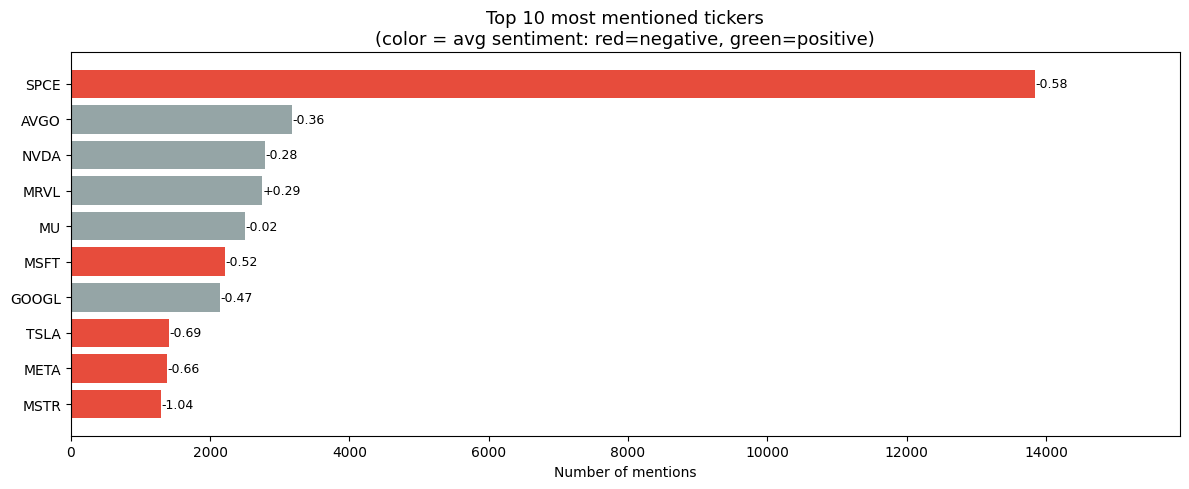

In [4]:
# ── CHART 1: Top tickers by mention count ────────────────────────────────────
top = ticker_summary.head(TOP_N)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#e74c3c' if s < -0.5 else '#2ecc71' if s > 0.5 else '#95a5a6'
          for s in top['avg_sentiment']]
bars = ax.barh(top['ticker'][::-1], top['mentions'][::-1], color=colors[::-1])

for bar, sent in zip(bars, top['avg_sentiment'][::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{sent:+.2f}', va='center', fontsize=9)

ax.set_xlabel('Number of mentions')
ax.set_title(f'Top {TOP_N} most mentioned tickers\n(color = avg sentiment: red=negative, green=positive)', fontsize=13)
ax.set_xlim(0, top['mentions'].max() * 1.15)
plt.tight_layout()
plt.savefig('output/chart_top_tickers.png', dpi=150, bbox_inches='tight')
plt.show()

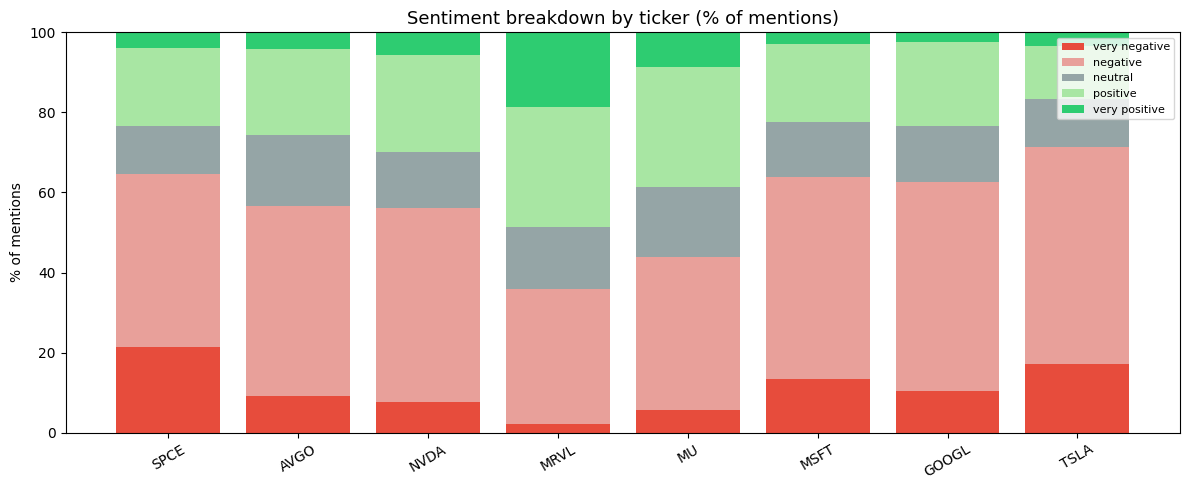

In [5]:
# ── CHART 2: Sentiment distribution for top tickers ──────────────────────────
top_tickers = ticker_summary.head(8)['ticker'].tolist()
sent_order  = ['very negative', 'negative', 'neutral', 'positive', 'very positive']

pivot = (
    sentiment_dist[sentiment_dist['ticker'].isin(top_tickers)]
    .pivot_table(index='ticker', columns='sentiment_label', values='count', fill_value=0)
    .reindex(columns=[s for s in sent_order if s in sentiment_dist['sentiment_label'].unique()])
    .reindex(top_tickers)
)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
bottom = np.zeros(len(pivot_pct))
for label in pivot_pct.columns:
    ax.bar(pivot_pct.index, pivot_pct[label], bottom=bottom,
           label=label, color=SENTIMENT_COLORS.get(label, '#ccc'))
    bottom += pivot_pct[label].values

ax.set_ylabel('% of mentions')
ax.set_title('Sentiment breakdown by ticker (% of mentions)', fontsize=13)
ax.legend(loc='upper right', fontsize=8)
ax.set_ylim(0, 100)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('output/chart_sentiment_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

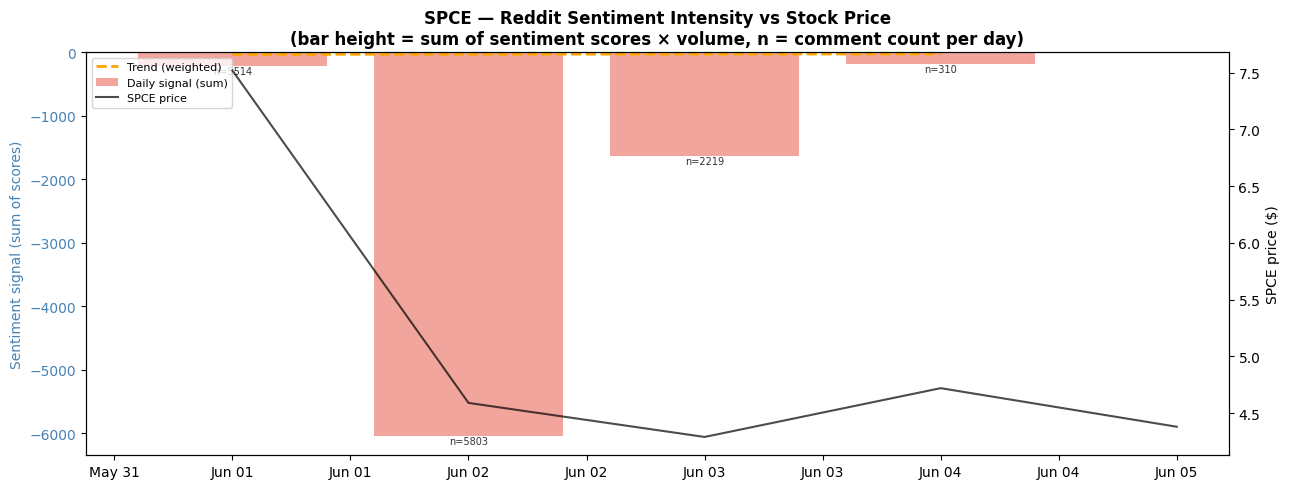

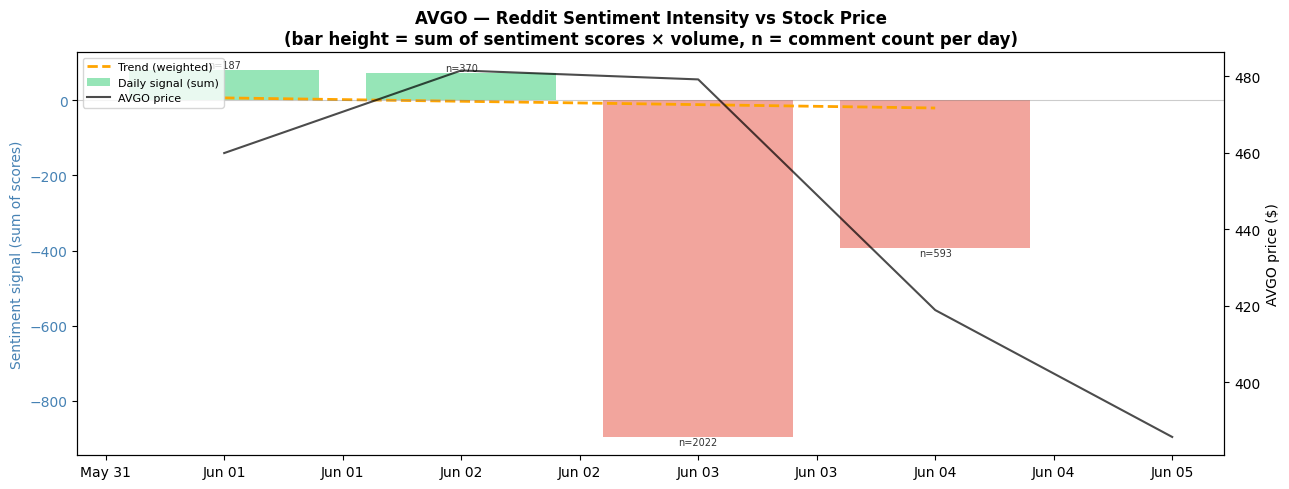

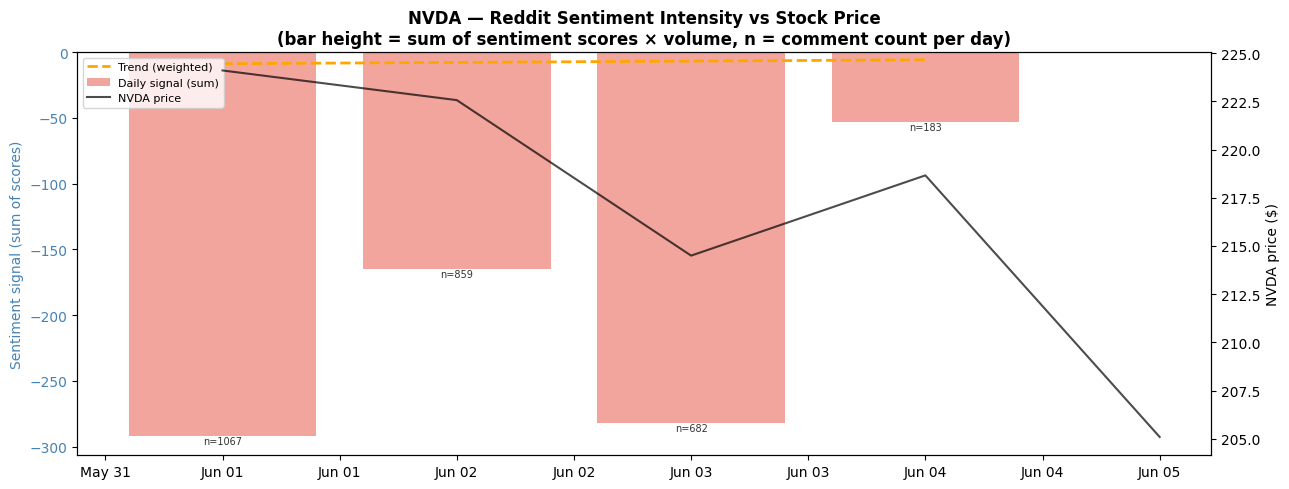

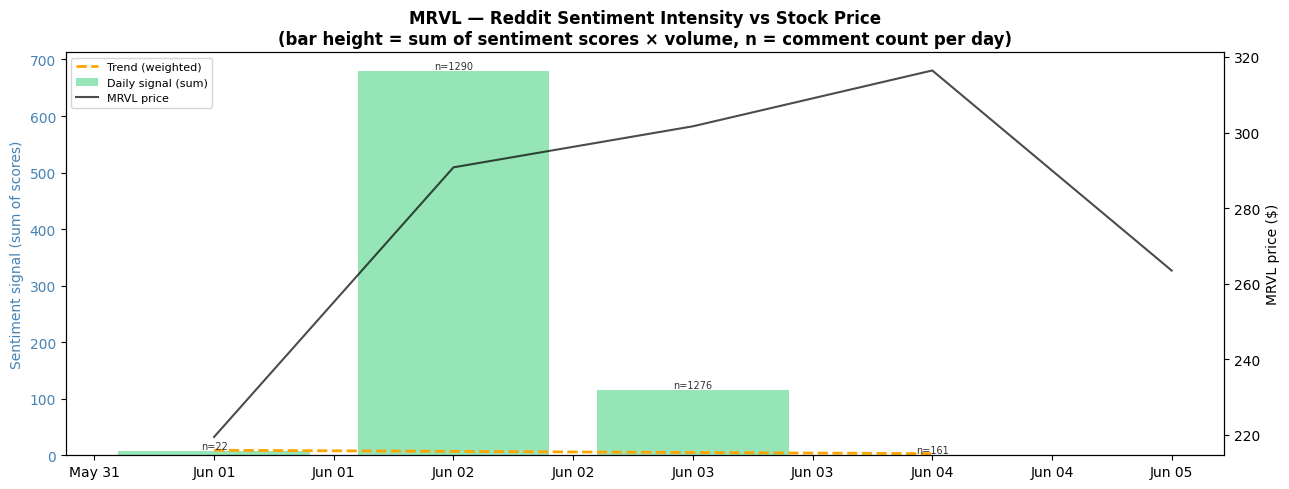

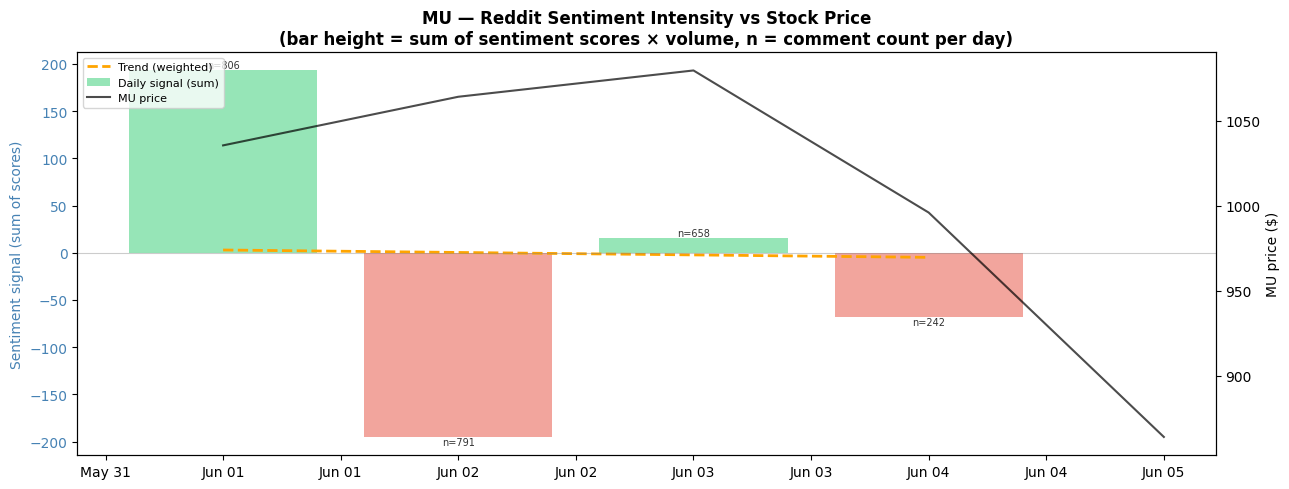

In [6]:
# ── CHART 3: Daily sentiment intensity + price overlay per ticker ─────────────
def plot_ticker(ticker: str):
    data = daily[daily['ticker'] == ticker].sort_values('date')
    if len(data) < 2:
        print(f'Not enough data for {ticker}')
        return

    fig, ax1 = plt.subplots(figsize=(13, 5))

    # Bar height = raw sum (shows volume × sentiment intensity)
    # Color = direction
    bar_colors = ['#e74c3c' if s < 0 else '#2ecc71' if s > 0 else '#95a5a6'
                  for s in data['sum_sentiment']]
    ax1.bar(data['date'], data['sum_sentiment'], color=bar_colors,
            alpha=0.5, width=0.8, label='Daily signal (sum)')

    # Trend line on weighted signal (volume-dampened)
    x = np.arange(len(data))
    z = np.polyfit(x, data['weighted_signal'], 1)
    ax1.plot(data['date'], np.poly1d(z)(x),
             '--', color='orange', linewidth=2, label='Trend (weighted)')

    # Annotate bars with comment count
    for _, row in data.iterrows():
        if row['n_comments'] >= 3:
            ax1.text(row['date'], row['sum_sentiment'],
                     f"n={int(row['n_comments'])}",
                     ha='center',
                     va='bottom' if row['sum_sentiment'] >= 0 else 'top',
                     fontsize=7, color='#333')

    ax1.axhline(0, color='gray', alpha=0.4, linewidth=0.8)
    ax1.set_ylabel('Sentiment signal (sum of scores)', color='steelblue')
    ax1.tick_params(axis='y', labelcolor='steelblue')

    # Price overlay
    if YFINANCE:
        try:
            start = data['date'].min() - pd.Timedelta(days=2)
            end   = data['date'].max() + pd.Timedelta(days=2)
            prices = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=True)
            if not prices.empty:
                ax2 = ax1.twinx()
                ax2.plot(prices.index, prices['Close'],
                         color='black', linewidth=1.5, alpha=0.7, label=f'{ticker} price')
                ax2.set_ylabel(f'{ticker} price ($)', color='black')
                ax2.tick_params(axis='y', labelcolor='black')
                lines2, labels2 = ax2.get_legend_handles_labels()
            else:
                lines2, labels2 = [], []
        except Exception as e:
            print(f'Price fetch failed: {e}')
            lines2, labels2 = [], []
    else:
        lines2, labels2 = [], []

    lines1, labels1 = ax1.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)
    ax1.set_title(
        f'{ticker} — Reddit Sentiment Intensity vs Stock Price\n'
        f'(bar height = sum of sentiment scores × volume, n = comment count per day)',
        fontsize=12, fontweight='bold'
    )
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f'output/chart_{ticker}_sentiment_price.png', dpi=150, bbox_inches='tight')
    plt.show()

# Plot top 5 tickers
for t in ticker_summary[ticker_summary['mentions'] >= MIN_MENTIONS]['ticker'].head(5):
    plot_ticker(t)

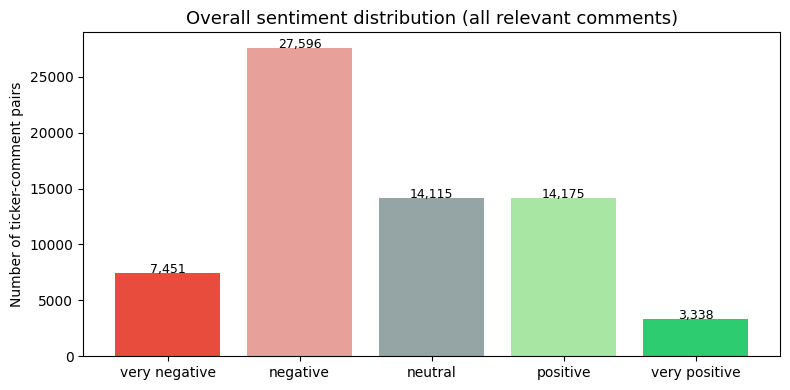


Total ticker-comment pairs: 66,675
Unique tickers mentioned: 2341
Most bearish ticker: BRC
Most bullish ticker: ECO


In [7]:
# ── CHART 4: Overall sentiment distribution ───────────────────────────────────
overall = df['sentiment_label'].value_counts().reindex(sent_order).dropna()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(overall.index, overall.values,
              color=[SENTIMENT_COLORS.get(s, '#ccc') for s in overall.index])
for bar, val in zip(bars, overall.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{val:,}', ha='center', fontsize=9)

ax.set_title('Overall sentiment distribution (all relevant comments)', fontsize=13)
ax.set_ylabel('Number of ticker-comment pairs')
plt.tight_layout()
plt.savefig('output/chart_overall_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTotal ticker-comment pairs: {len(df):,}')
print(f'Unique tickers mentioned: {df["ticker"].nunique()}')
print(f'Most bearish ticker: {ticker_summary.loc[ticker_summary["avg_sentiment"].idxmin(), "ticker"]}')
print(f'Most bullish ticker: {ticker_summary.loc[ticker_summary["avg_sentiment"].idxmax(), "ticker"]}')